## 10.1 The Geometric Perspective of Least Squares: Column Space


**Question**. What does it mean to say that $\hat{x}$ is an "approximate solution" to $A\vec{x} = \vec{b}$?

We know that in reality $A\vec{x} \neq \vec{b}$, and what we're really looking for is an approximate solution $\hat{x}$ such that $A\hat{x} \approx \vec{b}$.

In other words: "$\vec{b}$ is not in $C(A)$ so an exact solution is impossible. What we need is the $\vec{x}$ (that we're calling $\hat{x}$) that gets us to a vector $\hat{b}$ that *is* in $C(A)$ and is as close to $\vec{b}$ as possible."


#### Decomposing $\vec{b}$ into $\hat{b}$ and $\vec{\epsilon}$.

The least squares approximate solution solves $A\hat{x} = \hat{b}$. Let $\vec{b} = \hat{b} + \vec{\epsilon}$, where $\vec{\epsilon}$ is a vector of "errors" the model makes when doing its predictions.  

This perspective suggests we can think of $\vec{b}$ as the sum of two terms: the part of $\vec{b}$ that linear combinations of the columns of $A$ can predict (called $\hat{b}$), and the part of $\vec{b}$ for which the columns of $A$ hold no information, and thus no predictive power (called $\vec{\epsilon}$). See figure below.

This gives us

\begin{align}
& A\hat{x} = \hat{b} \\
& A\hat{x} = \vec{b} - \vec{\epsilon} \\
& A^TA\hat{x} = A^T(\vec{b} - \vec{\epsilon}) \\
& A^TA\hat{x} = A^T\vec{b} -A^T\vec{\epsilon}
\end{align}

Geometrically, $\vec{\epsilon}$ is *orthogonal to $C(A)$*, which means $\vec{\epsilon}$ is orthogonal to every column vector in $A$. This means that $A^T\vec{\epsilon} = \vec{0}$. Finally, to solve for $\hat{x}$ we can multiply from the left by inverse matrix $(A^TA)^{-1}$ giving

\begin{align}
\hat{x} = (A^TA)^{-1}A^T\vec{b}.
\end{align}

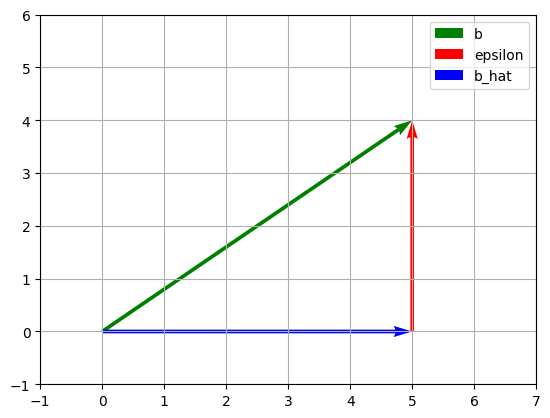

In [ ]:
# @title Plot
from matplotlib import pyplot as plt

V = np.array([5,4])
W = np.array([6,0])
W= np.dot(V,W)/np.dot(W,W)*W
X = V-W
fig, ax = plt.subplots()
ax.quiver(0, 0, V[0], V[1], angles='xy', scale_units='xy', scale=1, color='g')
ax.quiver(W[0], W[1], X[0], X[1], angles='xy', scale_units='xy', scale=1, color='r')
ax.quiver(0, 0, W[0], W[1], angles='xy', scale_units='xy', scale=1, color='b')
ax.set_xlim([-1, 7])
ax.set_ylim([-1,6])
plt.legend(['b', 'epsilon','b_hat'])
plt.grid()
plt.show()

**Question**. Where is $C(A)$ in the above graph?

**Exercise**. Find $\vec{\epsilon}$ for the Advertising-Expenditures example and verify that it is orthogonal to $C(A)$. What does this tell us about the least squares solution $\hat{x}$ being the "best" approximate solution to $A\vec{x} = \vec{b}$? How is $||\vec{\epsilon}||$ related to RMS?

In [ ]:
import numpy as np
import pandas as pd

V = np.array([[0, 2, 4, 0, 830], [1,0,0,1,0], [2,3,3,0,710], [3,0,3,1,290],[4,3,0,1,380],[5,2,0,0,210],[6,1,5,0,700],[7,1,4,1,440],[8,3,0,1,560],[9,4,2,0,1010]])
df_cust = pd.DataFrame(V,columns = ['cust_index','ad_1', 'ad_2', 'gender','dollars_spent'])
df_cust.head(10)

,cust_index,ad_1,ad_2,gender,dollars_spent
0,0,2,4,0,830
1,1,0,0,1,0
2,2,3,3,0,710
3,3,0,3,1,290
4,4,3,0,1,380
5,5,2,0,0,210
6,6,1,5,0,700
7,7,1,4,1,440
8,8,3,0,1,560
9,9,4,2,0,1010


In [ ]:
A = V[??, ??]
b = V[??, ??]

x_hat = ??

In [ ]:
b_hat = ??


## 10.2 Regression Models

The idea behind a general linear model is to use data collected on one or more  variables (numerical or categorical) as inputs to "estimate" a numerical output variable.

A *general model* that predicts an output from inputs takes some functional form:

\begin{align} y = f(x_1, x_2, ..., x_p). \end{align}

A *general linear model* means that we're building a model that involves solving a linear system of equations, and thus the functional form of $f$ (or a transformation of it, see *Logistic Regression*) is linear.

Regression models (and GLMs in general) are often the domain of statisticians, which has heavily influenced their notation and naming conventions.

### Linear Regression Models.

These are the simplest and most common versions of GLMs:


\begin{align} y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_px_p + \epsilon \hspace{.1in}. \end{align}

Here we use the statistics convention of an $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ (instead of $A\vec{x} = \vec{b}$). $\mathbf{X}$ is an $n \times (p + 1)$ "design" matrix, $\boldsymbol{\beta}$ is the model weights as a column vector, and $\mathbf{y}$ is the data vector that represents the variable our model is trying to predict.

**Terminology**:

1. $x_1, ... x_p$ are often called the "regressors", "independent", or "explanatory" variables. These variables are the columns in the design matrix $\mathbf{X}$. Note that these are no longer the elements of the least squares solution vector!

2. $y$ is often called the "dependent" or "response" variable.

3. $\beta_i$ are often called the model's "parameters" or "weights." Think of $\boldsymbol{\beta}$ as the "new" $\vec{x}$!

4. Regression models often call vector $\boldsymbol\epsilon$ the "residuals" or the "residual vector."

5. A model's prediction of $y_i$ is called $\hat{y}_i$. A model's error can be summarizes by the *Sum of Squared Residuals* (SSR) or *Sum of Squared Errors* (SSE):
\begin{align}
||\boldsymbol{\epsilon}||^2 = (y_1 - \hat{y}_1)^2 + (y_2 - \hat{y}_2)^2 + ... + (y_n - \hat{y}_n)^2.
\end{align}


#### How To Think About $\boldsymbol{\epsilon}$.

1. **Linear Algebra Point of View**. It's a vector that is the "part of $\mathbf{y}$ not in $C(\mathbf{X})$." If $\hat{\mathbf{y}}$ is in $C(\mathbf{X})$ then $\mathbf{X}^T\boldsymbol{\epsilon} = \mathbf{0}$.

2. **Statistical Point of View**. $\boldsymbol{\epsilon}$ is an "error" vector whose elements are often randomly drawn from the $N(0, \sigma)$ or some other distribution. The values are "independent" from the design matrix's data (a statistical property for random variables). Intuitively $\boldsymbol{\epsilon}$ represents "random fluctuations in the output variable $y$ that the model wasn't able to capture."

#### Linear Regression using Least Squares.

The least squares solution is:

\begin{align}
\boldsymbol{\hat{\beta}} = \mathbf{(X^TX)^{-1}X^Ty}.
\end{align}

We know that $\mathbf{y}$ is not in $C(\mathbf{X})$. Let $\mathbf{\hat{y}}$ be the part of $\mathbf{y}$ that is in $C(\mathbf{X})$. Then $\mathbf{y} = \mathbf{\hat{y}} + \boldsymbol{\epsilon}$, where $\boldsymbol{\epsilon}$ is a vector of values orthogonal to $C(\mathbf{X})$.

Estimating this model involves estimates of $\beta_i$:

\begin{align} \hat{y} = \hat{\beta}_0 + \hat{\beta}_1x_1 + \hat{\beta}_2x_2 + ... + \hat{\beta}_px_p.\end{align}

**Question**. A common point of confusion with students often comes from the fact that the model above has no $\epsilon$ error vector. Can you explain why this is the case?

**Example**. Suppose that the underlying relationship between $y$ and $x_1$ is known to be

\begin{align}
y = \beta_0 + \beta_1x_1 + \epsilon.
\end{align}

Find the regression model with
\begin{align}
\mathbf{X} = \begin{bmatrix}
    1 & -1 \\
    1 & 3 \\
    1 & 5
    \end{bmatrix},
    \boldsymbol{\beta} = \begin{bmatrix}
    \beta_0 \\
    \beta_1
    \end{bmatrix},
  \mathbf{y} = \begin{bmatrix}
    2 \\
    5 \\
    10
    \end{bmatrix}.
\end{align}

In [ ]:
import numpy as np

x_1 = np.array([[-1], [3], [5]])
y = np.array([[2], [5], [10]])

X = np.concatenate((np.ones((3,1)), x_1), axis = 1)
X

In [ ]:
beta_hat = ??

**Exercise**. Write out and interpret the full regression model.

\begin{align}
\hat{y} =
\end{align}

**Exercise**. Find and interpret $\boldsymbol{\epsilon}$. Then use it to find the SSR.

### The Line-Fitting Perspective of Linear Regression.

One way to visualize a linear regression model is to plot the model as a line through a scatter-plot.

Let's see how this works for our previous example. How can we interpret the vertical distances between the line and the points?

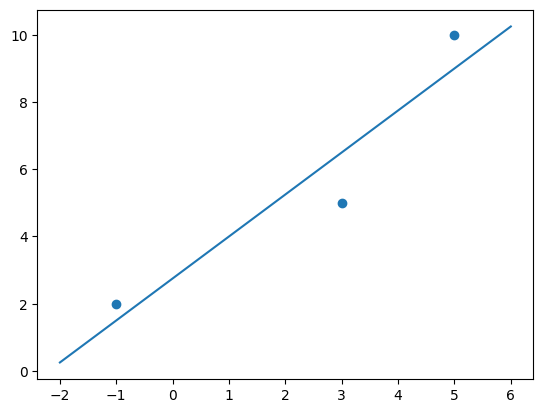

In [ ]:
import matplotlib.pyplot as plt

beta_hat = np.linalg.inv(X.T@X)@X.T@y
_ = plt.scatter(X[:,1:],y)
xs = np.linspace(-2, 6, 100)
y_hat = beta_hat[0] + beta_hat[1]*xs
_ = plt.plot(xs,y_hat)

## 10.4 Class Exercise

Construct a *linear regression model* for the Advertising-Expenditures dataset. How does this model differ from the one we did earlier?

In [ ]:
import numpy as np
import pandas as pd

V = np.array([[0, 2, 4, 0, 830], [1,0,0,1,0], [2,3,3,0,710], [3,0,3,1,290],[4,3,0,1,380],[5,2,0,0,210],[6,1,5,0,700],[7,1,4,1,440],[8,3,0,1,560],[9,4,2,0,1010]])
df_cust = pd.DataFrame(V,columns = ['cust_index','ad_1', 'ad_2', 'gender','dollars_spent'])
df_cust.head(10)

,cust_index,ad_1,ad_2,gender,dollars_spent
0,0,2,4,0,830
1,1,0,0,1,0
2,2,3,3,0,710
3,3,0,3,1,290
4,4,3,0,1,380
5,5,2,0,0,210
6,6,1,5,0,700
7,7,1,4,1,440
8,8,3,0,1,560
9,9,4,2,0,1010


In [ ]:
X = ??
y = ??

beta_hat = ??
y_hat = ??

SSR = ??